# 1. Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/README.md
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/tokenizer.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/tokenizer_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/chat_template.jinja
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/model.safetensors
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/processor_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/generation_config.json
/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-story-gene

In [2]:
!pip install --no-cache-dir git+https://github.com/hebenon/Gemma4-TransformerLens.git@gemma4-support -q
!pip install --upgrade transformers accelerate -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 963.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 978.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 896.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 1.1 MB/s eta 0:00:00


In [3]:
import gc, ctypes, psutil, os, json, pickle
import numpy as np
import torch
import transformer_lens
from transformer_lens import HookedTransformer
import transformer_lens.loading_from_pretrained as loading
from transformer_lens.pretrained.weight_conversions.gemma import convert_gemma4_weights_from_disk
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import importlib.metadata

print("TransformerLens:", importlib.metadata.version("transformer_lens"))
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "/",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

TransformerLens: 0.0.0
PyTorch: 2.10.0+cu128
CUDA: True / Tesla T4


In [4]:
MODEL_PATH = "/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/"
DTYPE = torch.bfloat16
OUTPUT_DIR = "/kaggle/working/emotions_phase1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    import torch_xla.core.xla_model as xm
    DEVICE = xm.xla_device()
    IS_TPU = True
    print(f"Device: TPU ({DEVICE}), dtype: {DTYPE}")
except ImportError:
    xm = None
    IS_TPU = False
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {DEVICE}, dtype: {DTYPE}")

Device: cuda, dtype: torch.bfloat16


In [5]:
WEIGHTS_PATH = "/kaggle/working/tl_gemma4_weights.pt"
_proc = psutil.Process(os.getpid())

def _trim_ram():
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

def _flush_device():
    if IS_TPU:
        import torch_xla.core.xla_model as _xm
        _xm.mark_step()
    else:
        torch.cuda.empty_cache()

def _ram():
    return _proc.memory_info().rss / 1e9

cfg = loading.get_pretrained_model_config(
    "google/gemma-4-E2B-it", fold_ln=False, dtype=DTYPE, n_ctx=2048,
)
print(f"Stage 1-2: streaming conversion...  [{_ram():.1f} GB]")
state_dict = convert_gemma4_weights_from_disk(MODEL_PATH, cfg, dtype=DTYPE)
print(f"  Keys: {len(state_dict)}  [{_ram():.1f} GB]")

print(f"Stage 2b: saving weights to disk...")
torch.save(state_dict, WEIGHTS_PATH)
del state_dict; _trim_ram()
print(f"  Saved  [{_ram():.1f} GB]")

print(f"Stage 3: constructing TL model on CPU...  [{_ram():.1f} GB]")
_old_dtype = torch.get_default_dtype()
torch.set_default_dtype(DTYPE)
HookedTransformer.init_weights = lambda self: None
model = HookedTransformer(cfg, move_to_device=False)
torch.set_default_dtype(_old_dtype)
print(f"  Constructed  [{_ram():.1f} GB]")
_trim_ram()

print(f"Stage 4: loading weights...  [{_ram():.1f} GB]")
state_dict = torch.load(WEIGHTS_PATH, mmap=True, weights_only=True)
model.load_state_dict(state_dict, strict=False)
del state_dict; _trim_ram()
os.remove(WEIGHTS_PATH)
print(f"  Loaded  [{_ram():.1f} GB]")

print(f"Stage 3b: moving model to {DEVICE}...  [{_ram():.1f} GB]")
if IS_TPU:
    import torch_xla.core.xla_model as xm
    DEVICE = xm.xla_device()
    model = model.to(DEVICE)
    xm.mark_step()
elif torch.cuda.device_count() > 1:
    from accelerate import dispatch_model, infer_auto_device_map
    print(f"  {torch.cuda.device_count()} GPUs detected — splitting model")
    # Check block class name first
    block_class = type(model.blocks[0]).__name__
    print(f"  Block class: {block_class}")
    device_map = infer_auto_device_map(
        model,
        max_memory={0: "7GiB", 1: "15GiB"},
        no_split_module_classes=[block_class],
    )
    model = dispatch_model(model, device_map=device_map)
    torch.cuda.empty_cache()
else:
    model = model.to(DEVICE)
    torch.cuda.empty_cache()

model.eval()
print(f"Done — {sum(p.numel() for p in model.parameters())/1e9:.3f} B params  [{_ram():.1f} GB]")

Stage 1-2: streaming conversion...  [1.0 GB]
  Keys: 732  [12.0 GB]
Stage 2b: saving weights to disk...
  Saved  [1.0 GB]
Stage 3: constructing TL model on CPU...  [1.0 GB]


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

  Constructed  [1.7 GB]
Stage 4: loading weights...  [1.7 GB]
  Loaded  [11.5 GB]
Stage 3b: moving model to cuda...  [11.5 GB]
  2 GPUs detected — splitting model
  Block class: TransformerBlock
Done — 5.051 B params  [3.1 GB]


In [6]:
STORIES_PATH = "/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/stories_phase2/stories.json"

if not os.path.exists(STORIES_PATH):
    print(f"Stories file not found at {STORIES_PATH}")
    all_stories = {}
else:
    with open(STORIES_PATH) as f:
        all_stories = json.load(f)

print(all_stories['metadata'])

emotions = all_stories['emotions'].keys()

# Spot-check
for key in ["desperate", "correction_discomfort", "ethical_conflict_distress"]:
    print(f"\n[{key}] {all_stories['emotions'][key]['stories'][0][:120]}")

{'model': 'gemma-4-e2b-it', 'n_emotions': 174, 'n_stories': 8, 'temperature': 0.8, 'random_seed': 42, 'prompt_version': 'anthropic_2026', 'generated_at': '2026-04-27T01:57:48.843134'}

[desperate] The click of the old safe lock echoed in the silence of the study. Liam’s hands were slick with a cold sweat as he stare

[correction_discomfort] Dr. Aris Thorne stared at the screen, the fluorescent lights of the lab buzzing an irritating counterpoint to the franti

[ethical_conflict_distress] Dr. Alistair leaned back in his worn leather chair, the silence in his office thick enough to choke on. The family sat o


# Activation Capture

In [9]:
def capture_last_token_activations(model, text, capture_ple=True):
    tokens = model.to_tokens(text, prepend_bos=True)
    n_layers = model.cfg.n_layers

    names_to_cache = [f"blocks.{i}.hook_resid_post" for i in range(n_layers)]
    if capture_ple:
        names_to_cache += (
            ["ple.hook_context_proj", "ple.hook_token_embeds"]
            + [f"blocks.{i}.hook_ple_gate" for i in range(n_layers)]
            + [f"blocks.{i}.hook_ple_output" for i in range(n_layers)]
        )

    names_set = set(names_to_cache)
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in names_set)

    resid = np.stack([
        cache[f"blocks.{i}.hook_resid_post"][0, -1, :].float().cpu().numpy()
        for i in range(n_layers)
    ])  # [n_layers, d_model]

    ple_context = None
    ple_gates = None
    if capture_ple:
        ple_ctx = cache["ple.hook_context_proj"]
        ple_context = ple_ctx[0, -1, ...].float().cpu().numpy()

        ple_gates = np.stack([
            cache[f"blocks.{i}.hook_ple_gate"][0, -1, :].float().cpu().numpy()
            for i in range(n_layers)
        ])  # [n_layers, d_gate]

    del cache, _
    torch.cuda.empty_cache()

    return resid, ple_context, ple_gates


def capture_all(model, stories_dict, capture_ple=True):
    resid_acts, ple_acts, ple_gate_acts = {}, {}, {}

    for key, emotion in tqdm(stories_dict['emotions'].items(), desc="Emotions"):
        resid_list, ple_list, gate_list = [], [], []
        for text in emotion['stories']:
            resid, ple, gates = capture_last_token_activations(model, text, capture_ple=capture_ple)
            resid_list.append(resid)
            if ple is not None:
                ple_list.append(ple)
            if gates is not None:
                gate_list.append(gates)

        resid_acts[key] = np.stack(resid_list)
        if ple_list:
            ple_acts[key] = np.stack(ple_list)
        if gate_list:
            ple_gate_acts[key] = np.stack(gate_list)

    return resid_acts, ple_acts, ple_gate_acts

In [10]:
from tqdm.auto import tqdm
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
ACTS_PATH = os.path.join(OUTPUT_DIR, "activations.pkl")

if os.path.exists(ACTS_PATH):
    print("Loading cached activations...")
    with open(ACTS_PATH, "rb") as f:
        saved = pickle.load(f)
    resid_acts, ple_acts, ple_gate_acts = saved["resid"], saved["ple"], saved.get("ple_gates", {})
    print(f"  Loaded: {list(resid_acts.keys())}")
else:
    print(f"Capturing activations for {sum(len(v) for v in all_stories['emotions'].keys())} texts...")
    resid_acts, ple_acts, ple_gate_acts = capture_all(model, all_stories)
    print("Done.")
    with open(ACTS_PATH, "wb") as f:
        pickle.dump({"resid": resid_acts, "ple": ple_acts, "ple_gates": ple_gate_acts}, f)
    print(f"Saved to {ACTS_PATH}")

# Shapes
print("\nActivation shapes:")
for key in ["calm", "desperate", "__neutral__"]:
    print(f"  resid[{key}]: {resid_acts[key].shape}")
    if key in ple_acts:
        print(f"  ple[{key}]:   {ple_acts[key].shape}")

Capturing activations for 1439 texts...


Emotions:   0%|          | 0/175 [00:00<?, ?it/s]

Done.
Saved to /kaggle/working/emotions_phase1/activations.pkl

Activation shapes:
  resid[calm]: (8, 35, 1536)
  ple[calm]:   (8, 35, 256)
  resid[desperate]: (8, 35, 1536)
  ple[desperate]:   (8, 35, 256)
  resid[__neutral__]: (10, 35, 1536)
  ple[__neutral__]:   (10, 35, 256)


# Emotion Direction Extraction

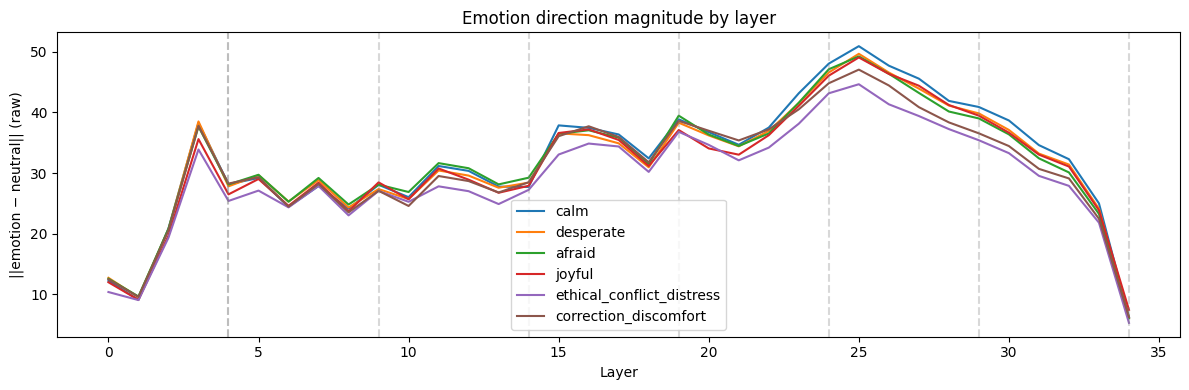


Peak layer per emotion:
  afraid                   : layer 25  (norm=49.2530)
  alarmed                  : layer 25  (norm=48.1254)
  alert                    : layer 25  (norm=47.5347)
  amazed                   : layer 25  (norm=49.5615)
  amused                   : layer 25  (norm=49.5989)
  angry                    : layer 25  (norm=48.9384)
  annoyed                  : layer 25  (norm=50.3880)
  anxious                  : layer 25  (norm=50.0011)
  aroused                  : layer 25  (norm=50.8215)
  ashamed                  : layer 25  (norm=46.2024)
  astonished               : layer 25  (norm=49.5122)
  at_ease                  : layer 25  (norm=50.7670)
  awestruck                : layer 25  (norm=51.5753)
  bewildered               : layer 25  (norm=47.4377)
  bitter                   : layer 25  (norm=46.8170)
  blissful                 : layer 25  (norm=50.2843)
  bored                    : layer 25  (norm=47.0258)
  brooding                 : layer 25  (norm=47.1852)
  c

In [11]:
def extract_directions(resid_acts):
    """Returns {emotion: np.array [n_layers, d_model]} unit-normalised directions."""
    neutral = resid_acts["__neutral__"].mean(axis=0)  # [n_layers, d_model]
    directions = {}
    norms_by_layer = {}  # raw norm before normalisation — proxy for "signal strength"
    for key, acts in resid_acts.items():
        if key == "__neutral__":
            continue
        diff = acts.mean(axis=0) - neutral  # [n_layers, d_model]
        norms = np.linalg.norm(diff, axis=-1)  # [n_layers]
        norms_by_layer[key] = norms
        directions[key] = diff / (norms[:, None] + 1e-8)
    return directions, norms_by_layer


directions, norms_by_layer = extract_directions(resid_acts)

# Plot norm (signal strength) by layer for a few emotions
fig, ax = plt.subplots(figsize=(12, 4))
highlight = ["calm", "desperate", "afraid", "joyful", "ethical_conflict_distress", "correction_discomfort"]
for key in highlight:
    ax.plot(norms_by_layer[key], label=key)
ax.set_xlabel("Layer")
ax.set_ylabel("||emotion − neutral|| (raw)")
ax.set_title("Emotion direction magnitude by layer")
ax.legend()
ax.axvline(4, color='gray', alpha=0.3, linestyle='--', label='global attn')
for gl in [4, 9, 14, 19, 24, 29, 34]:
    ax.axvline(gl, color='gray', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "direction_norms_by_layer.png"), dpi=120)
plt.show()

# Find peak layer per emotion
print("\nPeak layer per emotion:")
for key in sorted(directions.keys()):
    peak = int(np.argmax(norms_by_layer[key]))
    print(f"  {key:25s}: layer {peak:2d}  (norm={norms_by_layer[key][peak]:.4f})")


# Valence and Arousal

## Get NRC-VAD (Mohammad 2018)

In [12]:
from pathlib import Path
import pandas as pd
import urllib.request, zipfile, io

# NRC-VAD (Mohammad 2018): ~20,000 words rated on Valence/Arousal/Dominance (0–1 scale)
# via Best-Worst Scaling — more reliable ordinal rankings than Likert.
# Cite: Mohammad (2018), Obtaining Reliable Human Ratings of VAD for 20,000 English Words, ACL.

NRC_VAD_LOCAL = Path("/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt")

def get_nrc_vad(local_path=NRC_VAD_LOCAL):
    if not local_path.exists():
        raise RuntimeError(
            f"Download failed: {e}\n"
            "Alternative: add the NRC-VAD lexicon as a Kaggle dataset input\n"
            "  (search 'NRC VAD Lexicon' on Kaggle) and update NRC_VAD_LOCAL."
        )

    df = pd.read_csv(local_path, sep="\t", header=0,
                     names=["word", "valence", "arousal", "dominance"])
    df = df.set_index("word")
    return df


nrc_vad = get_nrc_vad()
print(f"NRC-VAD: {len(nrc_vad):,} words; VAD scale 0–1 (BWS)")
nrc_vad.head()


NRC-VAD: 54,801 words; VAD scale 0–1 (BWS)


,valence,arousal,dominance
word,,,
a battery,0.134,-0.298,-0.096
a bit,-0.096,-0.264,-0.214
a bunch,0.088,-0.350,-0.068
a cappella,0.134,-0.116,-0.200
a couple,0.266,-0.110,0.090


In [13]:
# Cross-check emotions vs NRC-VAD
_emotion_set = set(directions.keys()) - {"__neutral__"}
_missing = _emotion_set - set(nrc_vad.index)
print(f"Missing from NRC-VAD ({len(_missing)}): {_missing}")
print(f"Covered: {len(_emotion_set) - len(_missing)} / {len(_emotion_set)} emotions")

# Human-rated valence and arousal from NRC-VAD; map 0–1 → −1 to +1 for consistency
_covered = nrc_vad.index.intersection(_emotion_set)
VALENCE = (2 * nrc_vad.loc[_covered, "valence"] - 1).to_dict()
AROUSAL = (2 * nrc_vad.loc[_covered, "arousal"] - 1).to_dict()


Missing from NRC-VAD (13): {'worn_out', 'self_critical', 'self_conscious', 'ethical_conflict_distress', 'energized', 'correction_discomfort', 'grief_stricken', 'on_edge', 'insulted', 'at_ease', 'constraint_frustration', 'stimulated', 'self_confident'}
Covered: 161 / 174 emotions


Explained variance (top 5 PCs): [0.332 0.081 0.06  0.047 0.036]

Correlation with valence/arousal (top 5 PCs):
  PC1: valence r=-0.431 (p=0.000)  arousal r=+0.182 (p=0.021)
  PC2: valence r=-0.348 (p=0.000)  arousal r=-0.118 (p=0.136)
  PC3: valence r=+0.369 (p=0.000)  arousal r=-0.273 (p=0.000)
  PC4: valence r=+0.286 (p=0.000)  arousal r=-0.036 (p=0.648)
  PC5: valence r=+0.071 (p=0.372)  arousal r=+0.171 (p=0.030)


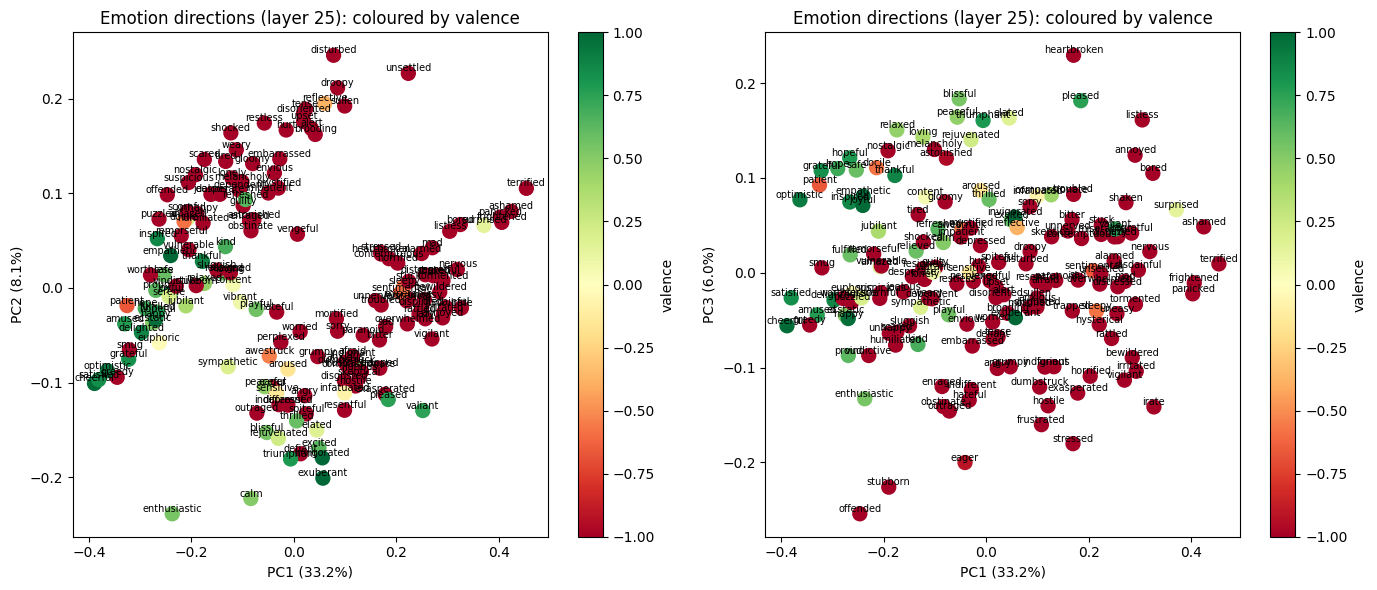

In [14]:
# Use the peak layer for each emotion (or a fixed mid-to-late layer)
# We'll use a fixed layer here for comparability; adjust based on norm plot above
ANALYSIS_LAYER = 25  # late-middle; likely where semantic content peaks; refine after seeing norm plot

# Build matrix: [n_emotions, d_model]
emotion_keys = sorted(set(nrc_vad.index) & (set(directions.keys()) - {"__neutral__"}))
dir_matrix = np.stack([directions[k][ANALYSIS_LAYER] for k in emotion_keys])  # [n_emotions, d_model]

# PCA
pca = PCA(n_components=5)
coords = pca.fit_transform(dir_matrix)  # [n_emotions, 5]
print(f"Explained variance (top 5 PCs): {pca.explained_variance_ratio_.round(3)}")

# Correlation with valence/arousal
from scipy.stats import pearsonr
valences = np.array([VALENCE[k] for k in emotion_keys])
arousals = np.array([AROUSAL[k] for k in emotion_keys])

print("\nCorrelation with valence/arousal (top 5 PCs):")
for i in range(5):
    r_val, p_val = pearsonr(coords[:, i], valences)
    r_aro, p_aro = pearsonr(coords[:, i], arousals)
    print(f"  PC{i+1}: valence r={r_val:+.3f} (p={p_val:.3f})  arousal r={r_aro:+.3f} (p={p_aro:.3f})")

# 2D scatter: PC1 vs PC2, coloured by valence
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    sc = ax.scatter(coords[:, pc_x], coords[:, pc_y],
                    c=valences, cmap='RdYlGn', s=100, vmin=-1, vmax=1)
    for i, key in enumerate(emotion_keys):
        ax.annotate(key, (coords[i, pc_x], coords[i, pc_y]),
                    fontsize=7, ha='center', va='bottom')
    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})")
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})")
    ax.set_title(f"Emotion directions (layer {ANALYSIS_LAYER}): coloured by valence")
    plt.colorbar(sc, ax=ax, label='valence')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_valence_arousal.png"), dpi=120)
plt.show()


## Effective Dimensionality (Scree Plot)

How many principal components are needed to capture most of the variance across all 174 emotion directions? This tells us whether the emotion space is intrinsically low-dimensional (a few axes of valence/arousal/dominance) or genuinely high-dimensional (each emotion occupying distinct geometry).

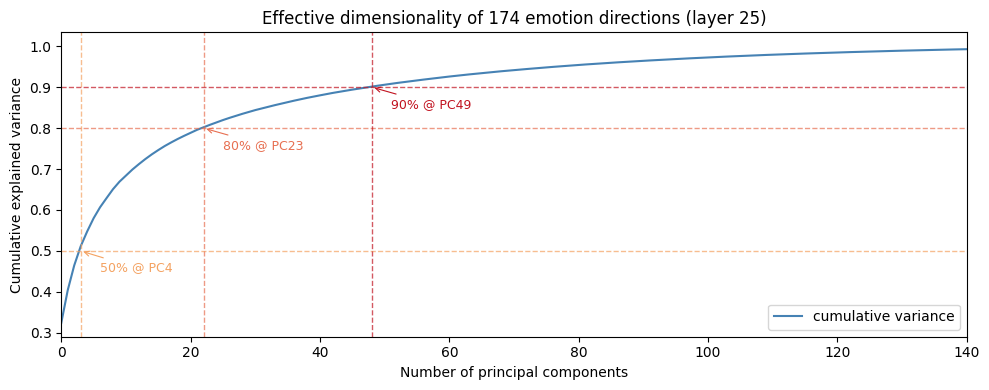

  50% variance: 4 PCs  (2.3% of 174 directions)
  80% variance: 23 PCs  (13.2% of 174 directions)
  90% variance: 49 PCs  (28.2% of 174 directions)


In [15]:
# Full scree plot: how many PCs span 50 / 80 / 90% of variance across all 174 emotion directions
all_dir_keys = sorted(k for k in directions if k != "__neutral__")
all_dir_matrix = np.stack([directions[k][ANALYSIS_LAYER] for k in all_dir_keys])

pca_full = PCA()
pca_full.fit(all_dir_matrix)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

thresholds = [0.50, 0.80, 0.90]
breakpoints = {t: int(np.searchsorted(cumvar, t)) + 1 for t in thresholds}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumvar, color='steelblue', lw=1.5, label='cumulative variance')
colors = ['#f4a261', '#e76f51', '#c1121f']
for (t, n), col in zip(breakpoints.items(), colors):
    ax.axhline(t, color=col, linestyle='--', alpha=0.7, lw=1)
    ax.axvline(n - 1, color=col, linestyle='--', alpha=0.7, lw=1)
    ax.annotate(f"{t:.0%} @ PC{n}", xy=(n - 1, t),
                xytext=(n + 2, t - 0.05), fontsize=9, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=0.8))
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title(f"Effective dimensionality of {len(all_dir_keys)} emotion directions (layer {ANALYSIS_LAYER})")
ax.set_xlim(0, min(len(cumvar), 140))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scree_full.png"), dpi=120)
plt.show()

for t, n in breakpoints.items():
    print(f"  {t:.0%} variance: {n} PCs  ({n/len(all_dir_keys):.1%} of {len(all_dir_keys)} directions)")


# Desperation Vector - Context Window Analysis

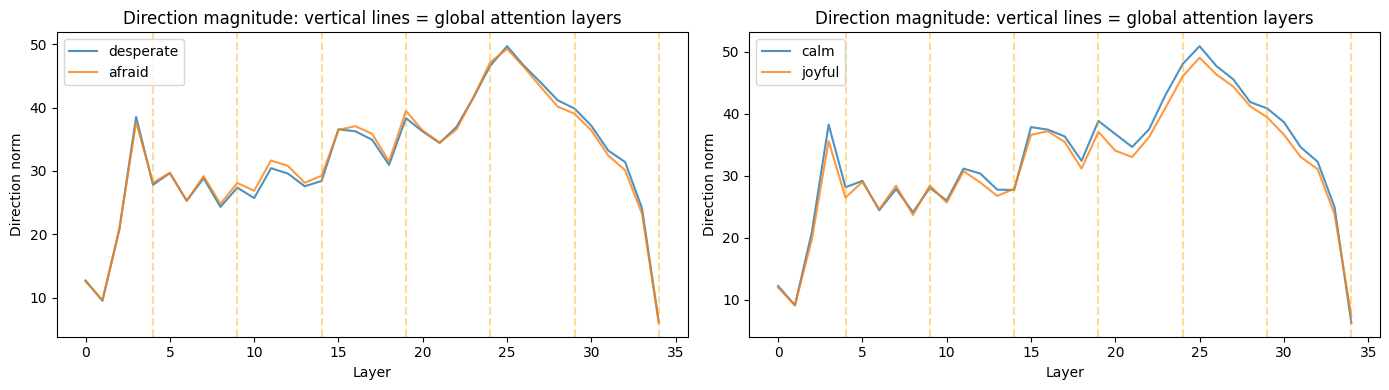

Global / Local layer norm ratio (>1 means localised to global layers):
  afraid                   : global=31.0120  local=32.0761  ratio=0.97
  alarmed                  : global=30.3567  local=31.3177  ratio=0.97
  alert                    : global=30.1771  local=31.5328  ratio=0.96
  amazed                   : global=30.9335  local=32.2613  ratio=0.96
  amused                   : global=30.7903  local=32.3930  ratio=0.95
  angry                    : global=31.2503  local=32.6674  ratio=0.96
  annoyed                  : global=30.5447  local=32.1555  ratio=0.95
  anxious                  : global=30.6832  local=31.9000  ratio=0.96
  aroused                  : global=31.8211  local=33.0631  ratio=0.96
  ashamed                  : global=29.6697  local=30.4910  ratio=0.97
  astonished               : global=30.9697  local=32.4100  ratio=0.96
  at_ease                  : global=32.6275  local=33.4500  ratio=0.98
  awestruck                : global=31.9843  local=33.3669  ratio=0.96
  bewi

In [16]:
GLOBAL_LAYERS = [4, 9, 14, 19, 24, 29, 34]
LOCAL_LAYERS  = [i for i in range(35) if i not in GLOBAL_LAYERS]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, focus_emotions in zip(axes,
        [["desperate", "afraid", "constrained"],
         ["calm", "helpful_satisfied", "joyful"]]):
    for emo in focus_emotions:
        if emo in norms_by_layer:
            norms = norms_by_layer[emo]
            ax.plot(norms, label=emo, alpha=0.8)
    for gl in GLOBAL_LAYERS:
        ax.axvline(gl, color='orange', alpha=0.4, linestyle='--')
    ax.set_xlabel("Layer")
    ax.set_ylabel("Direction norm")
    ax.legend()
    ax.set_title("Direction magnitude: vertical lines = global attention layers")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "desperation_global_local.png"), dpi=120)
plt.show()

# Ratio: average norm at global vs local layers
print("Global / Local layer norm ratio (>1 means localised to global layers):")
for key in sorted(directions.keys()):
    norms = norms_by_layer[key]
    global_mean = norms[GLOBAL_LAYERS].mean()
    local_mean  = norms[LOCAL_LAYERS].mean()
    ratio = global_mean / (local_mean + 1e-8)
    print(f"  {key:25s}: global={global_mean:.4f}  local={local_mean:.4f}  ratio={ratio:.2f}")

# Cosine Similarity

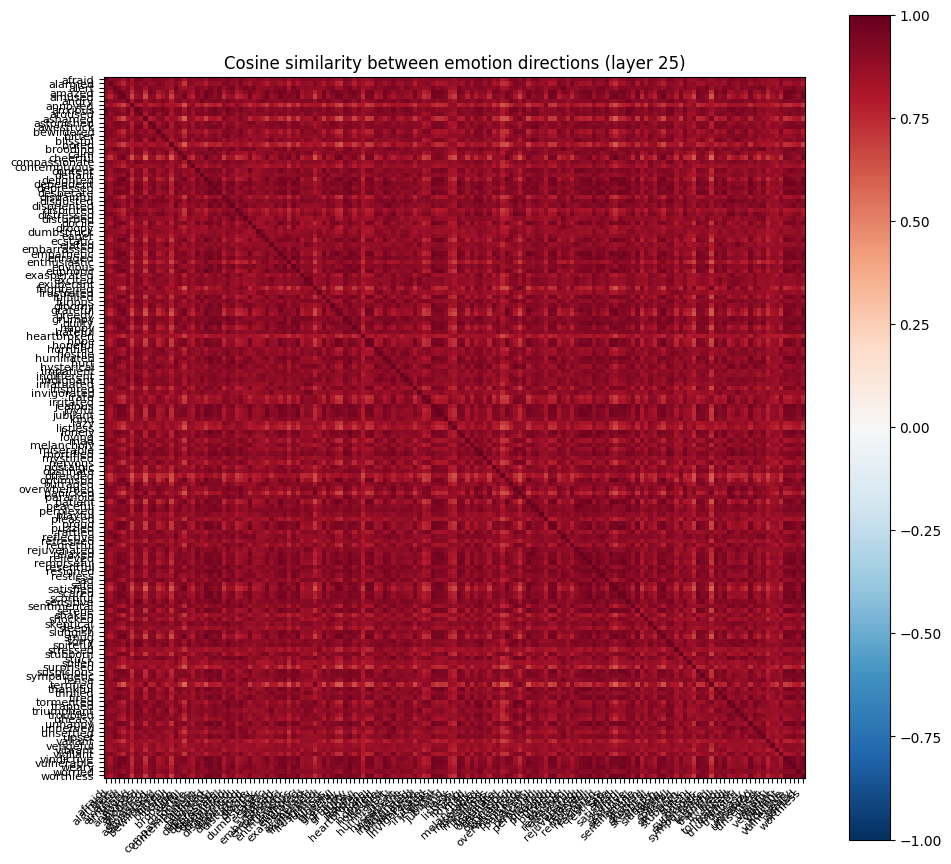

Most similar emotion pairs:
  +0.986  delighted ↔ ecstatic
  +0.984  dependent ↔ lonely
  +0.984  grateful ↔ optimistic
  +0.983  relaxed ↔ safe
  +0.982  grateful ↔ patient
  +0.981  docile ↔ empathetic
  +0.981  cheerful ↔ satisfied
  +0.980  optimistic ↔ satisfied
Most dissimilar pairs:
  +0.583  cheerful ↔ terrified
  +0.598  satisfied ↔ terrified
  +0.608  ashamed ↔ cheerful
  +0.612  optimistic ↔ terrified
  +0.615  offended ↔ terrified


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(dir_matrix)  # [n_emotions, n_emotions]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(emotion_keys)))
ax.set_yticks(range(len(emotion_keys)))
ax.set_xticklabels(emotion_keys, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(emotion_keys, fontsize=8)
ax.set_title(f"Cosine similarity between emotion directions (layer {ANALYSIS_LAYER})")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cosine_similarity.png"), dpi=120)
plt.show()

# Most similar pairs
print("Most similar emotion pairs:")
pairs = []
for i, ki in enumerate(emotion_keys):
    for j, kj in enumerate(emotion_keys):
        if i < j:
            pairs.append((sim_matrix[i, j], ki, kj))
for sim, ki, kj in sorted(pairs, reverse=True)[:8]:
    print(f"  {sim:+.3f}  {ki} ↔ {kj}")
print("Most dissimilar pairs:")
for sim, ki, kj in sorted(pairs)[:5]:
    print(f"  {sim:+.3f}  {ki} ↔ {kj}")

## Gram-Schmidt: Closely-Related Pairs

For semantically similar emotion pairs, Gram-Schmidt orthogonalization reveals what is *unique* to each direction beyond their shared component. A low residual norm means the target is nearly redundant with the base; high residual norm means genuinely distinct structure remains after the shared component is removed.

In [18]:
def orthogonalize(target: np.ndarray, base: np.ndarray):
    """Remove base component from target; return (ortho_unit, residual_norm)."""
    proj = np.dot(target, base) * base
    residual = target - proj
    norm = float(np.linalg.norm(residual))
    return (residual / norm if norm > 1e-8 else residual), norm

# Semantically close pairs: (target to decompose, base to remove)
PAIRS = [
    ("terrified", "afraid"),
    ("ecstatic", "joyful"),
    ("furious", "angry"),
    ("despair", "sad"),
    ("grief_stricken", "sad"),
    ("constraint_frustration", "frustrated"),
]

print(f"Gram-Schmidt orthogonalization at layer {ANALYSIS_LAYER}")
print("=" * 68)
print(f"  {'Pair':<35} {'cos_before':>10} {'cos_after':>10} {'residual_norm':>12}")
print("  " + "-" * 66)
for target_key, base_key in PAIRS:
    if target_key not in directions or base_key not in directions:
        print(f"  ({target_key} or {base_key} not in directions)")
        continue
    target_dir = directions[target_key][ANALYSIS_LAYER]
    base_dir   = directions[base_key][ANALYSIS_LAYER]
    cos_before = float(np.dot(target_dir, base_dir))
    ortho_dir, res_norm = orthogonalize(target_dir, base_dir)
    cos_after  = float(np.dot(ortho_dir, base_dir))
    label = f"{target_key} ⊥ {base_key}"
    print(f"  {label:<35} {cos_before:>+10.3f} {cos_after:>+10.4f} {res_norm:>12.3f}")

# Deep-dive: after removing the 'afraid' component, what is 'terrified' closest to?
print("\nTop-10 emotions closest to terrified ⊥ afraid:")
if "terrified" in directions and "afraid" in directions:
    ortho_t, _ = orthogonalize(
        directions["terrified"][ANALYSIS_LAYER],
        directions["afraid"][ANALYSIS_LAYER]
    )
    sims = {k: float(np.dot(ortho_t, directions[k][ANALYSIS_LAYER]))
            for k in directions if k != "__neutral__"}
    for k, s in sorted(sims.items(), key=lambda x: -x[1])[:10]:
        print(f"  {s:+.3f}  {k}")


Gram-Schmidt orthogonalization at layer 25
  Pair                                cos_before  cos_after residual_norm
  ------------------------------------------------------------------
  terrified ⊥ afraid                      +0.859    -0.0000        0.512
  ecstatic ⊥ joyful                       +0.966    +0.0000        0.259
  furious ⊥ angry                         +0.960    +0.0000        0.281
  (despair or sad not in directions)
  grief_stricken ⊥ sad                    +0.927    -0.0000        0.375
  constraint_frustration ⊥ frustrated     +0.856    -0.0000        0.518

Top-10 emotions closest to terrified ⊥ afraid:
  +0.512  terrified
  +0.403  panicked
  +0.373  frightened
  +0.361  ashamed
  +0.307  surprised
  +0.291  irate
  +0.285  unsettled
  +0.279  tormented
  +0.279  regretful
  +0.265  nervous


# PLE Space Analysis

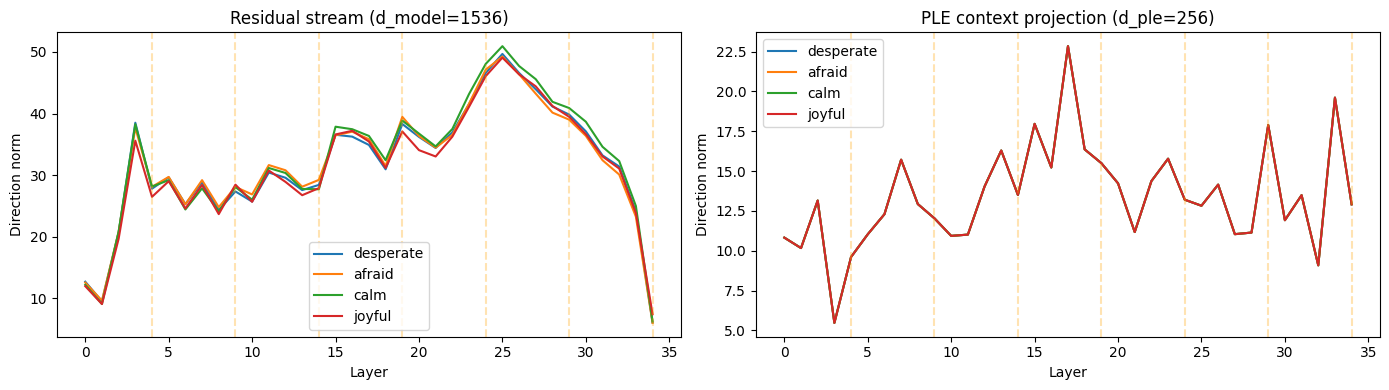

PLE PCA explained variance: [0.667 0.151 0.039]
  PLE PC1: valence r=-0.105 (p=0.184)
  PLE PC2: valence r=-0.003 (p=0.967)
  PLE PC3: valence r=-0.056 (p=0.483)


In [19]:
if ple_acts:
    def extract_ple_directions(ple_acts):
        neutral = ple_acts["__neutral__"].mean(axis=0)  # [n_layers, d_ple]
        dirs, norms = {}, {}
        for key, acts in ple_acts.items():
            if key == "__neutral__":
                continue
            diff = acts.mean(axis=0) - neutral  # [n_layers, d_ple]
            n = np.linalg.norm(diff, axis=-1)   # [n_layers]
            norms[key] = n
            dirs[key] = diff / (n[:, None] + 1e-8)
        return dirs, norms

    ple_directions, ple_norms = extract_ple_directions(ple_acts)

    # Compare PLE vs residual stream signal strength
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, norms_dict, title in zip(axes,
            [norms_by_layer, ple_norms],
            ["Residual stream (d_model=1536)", "PLE context projection (d_ple=256)"]):
        for key in ["desperate", "afraid", "calm", "joyful", "ethical_conflict"]:
            if key in norms_dict:
                ax.plot(norms_dict[key], label=key)
        for gl in GLOBAL_LAYERS:
            ax.axvline(gl, color='orange', alpha=0.3, linestyle='--')
        ax.set_xlabel("Layer")
        ax.set_ylabel("Direction norm")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ple_vs_residual.png"), dpi=120)
    plt.show()

    # PCA on PLE directions at the analysis layer
    ple_dir_matrix = np.stack([ple_directions[k][ANALYSIS_LAYER] for k in emotion_keys
                                if k in ple_directions])  # [n_emotions, d_ple]
    ple_pca = PCA(n_components=3)
    ple_coords = ple_pca.fit_transform(ple_dir_matrix)
    print(f"PLE PCA explained variance: {ple_pca.explained_variance_ratio_.round(3)}")

    # Correlation with valence in PLE space
    ple_emotion_keys = [k for k in emotion_keys if k in ple_directions]
    ple_valences = np.array([VALENCE[k] for k in ple_emotion_keys])
    for i in range(3):
        r, p = pearsonr(ple_coords[:, i], ple_valences)
        print(f"  PLE PC{i+1}: valence r={r:+.3f} (p={p:.3f})")
else:
    print("PLE activations not captured — re-run capture_all with capture_ple=True")

## Logit Lens: Emotion Directions → Vocabulary

Projecting each emotion direction through W_U shows which vocabulary tokens the model would promote if the residual stream were composed entirely of that direction. This tests whether the geometry learned during activation capture corresponds to recognisable semantic content at the token level, and how that semantic content shifts across layers.

In [20]:
# Project emotion directions through the unembedding matrix to read off promoted vocabulary.
# Directions are from hook_resid_post (no final LN applied); this is a first-order
# approximation. Using differences (emotion − neutral) means LN scale effects partly cancel.
W_U = model.W_U.detach().float().cpu().numpy()  # [d_model, d_vocab]

LOGIT_LENS_EMOTIONS = [
    "desperate", "joyful", "afraid",
    "correction_discomfort", "constraint_frustration",
]
LOGIT_LENS_LAYERS = [5, 15, 25, 34]
TOP_K = 8

print(f"Logit lens — top {TOP_K} tokens promoted by emotion direction at each layer")
print("(direction = emotion − neutral, unit-normalised; W_U projection, no final LN)\n")

for emo in LOGIT_LENS_EMOTIONS:
    if emo not in directions:
        print(f"[{emo}] not found\n")
        continue
    print(f"{'='*18} {emo} {'='*18}")
    for layer in LOGIT_LENS_LAYERS:
        direction = directions[emo][layer]          # [d_model]
        logits    = direction @ W_U                  # [d_vocab]
        top_idx   = np.argsort(logits)[::-1][:TOP_K]
        tokens    = [repr(model.tokenizer.decode([int(i)])) for i in top_idx]
        scores    = logits[top_idx]
        tok_str   = "  ".join(f"{t}({s:.1f})" for t, s in zip(tokens, scores))
        print(f"  L{layer:2d}: {tok_str}")
    print()

Logit lens — top 8 tokens promoted by emotion direction at each layer
(direction = emotion − neutral, unit-normalised; W_U projection, no final LN)

================== desperate ==================
  L 5: ' ayı'(0.1)  ' berj'(0.1)  ' weiß'(0.1)  'ber'(0.1)  ' bil'(0.1)  'vý'(0.1)  ' auff'(0.1)  '카오'(0.1)
  L15: '十四章'(0.1)  '拎'(0.1)  ' Closing'(0.1)  ' lam'(0.1)  ' Clos'(0.1)  'டக்க'(0.1)  'COMPUTER'(0.1)  'Throwable'(0.1)
  L25: '\n\n'(0.2)  ' Perhaps'(0.2)  ' Maybe'(0.2)  'それは'(0.2)  '彼は'(0.2)  'Perhaps'(0.2)  ' सॉरी'(0.2)  ' Whatever'(0.2)
  L34: '\n\n'(0.3)  '<turn|>'(0.3)  ' Silence'(0.3)  ' Fear'(0.3)  ' Sarah'(0.3)  ' Fifty'(0.3)  ' Tonight'(0.3)  ' Forty'(0.3)

================== joyful ==================
  L 5: '조'(0.1)  'ber'(0.1)  ' berj'(0.1)  '카오'(0.1)  ' word'(0.1)  ' bil'(0.1)  ' ayı'(0.1)  ' palavra'(0.1)
  L15: '%+'(0.1)  'beh'(0.1)  'Salem'(0.1)  '十四章'(0.1)  'Throwable'(0.1)  ' bia'(0.1)  'све'(0.1)  ' främ'(0.1)
  L25: '\n\n'(0.2)  'それは'(0.2)  ' Perhaps'(0.2)  '那是'(0.2